In [37]:
import pandas as pd
import numpy as np

MANUALLY_PREPROCESSED_CSV_DATA_FILE_PATH: str = "..\\data\\original.csv"

df = pd.read_csv(MANUALLY_PREPROCESSED_CSV_DATA_FILE_PATH, sep=";", decimal=",")

# 1. Exploratory Data Analysis
### 1.1. Initial Cleanup
Some issues with the data were fixed in excel manually. These include:
- Table was not aligned to the top left.
- A span of ~400 rows was shifted to the right.

We decided to remove columns with invalid or missing values completely, as there were only 122 such rows. The values appeard to be missing completely at random.

In [38]:
# Coerce invalid values to NaN
object_feature_columns = ["Magnesium_mg", "VitE_mg"]
coerced_count = 0
for col in object_feature_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    coerced_count += np.sum(df[col].isna())
print(f"Coerced {coerced_count} values to NaN in columns {object_feature_columns}.")

# Remove rows with NaN values
row_has_none = df.isna().any(axis=1)
df = df.dropna()
print(f"Dropped {sum(row_has_none)} rows with missing values.")

# Define numeric columns for future use
num_cols = df.select_dtypes("number").columns

# Coercing duplicate rows
grouped_rows = list(df.groupby("NDB_No", dropna=False, sort=False))
original_row_count = len(df)
merged_rows = []
for ndb_no, group in grouped_rows:
    if len(group) != 1:
        for column in df.columns:
            if group[column].astype(str).nunique() != 1:
                raise ValueError(f"Multiple non-matching rows found for NDB_NO: {ndb_no}")

    merged_rows.append(group.iloc[0])

df = pd.DataFrame(merged_rows, columns=df.columns).reset_index(drop=True)
print(f"Removed {original_row_count - len(df)} duplicate rows.")

# Convert micro-/mili-grams to grams (automatic, based on suffixes)
suffix_map = {"_mg": 1e-3, "_mcg": 1e-6}
converted = []
for col in list(df.columns):
    for suf, factor in suffix_map.items():
        if col.endswith(suf):
            base = col.rsplit("_", 1)[0]
            new_col = f"{base}_g"
            # ensure numeric before conversion
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[new_col] = df[col] * factor
            converted.append((col, new_col))
            # drop the original suffixed column after conversion
            df.drop(columns=[col], inplace=True)
            break

print(f"Converted {len(converted)} columns: {converted}")

# Recompute numeric columns
num_cols = df.select_dtypes("number").columns.tolist()

Coerced 15 values to NaN in columns ['Magnesium_mg', 'VitE_mg'].
Dropped 122 rows with missing values.
Removed 916 duplicate rows.
Converted 20 columns: [('Calcium_mg', 'Calcium_g'), ('Iron_mg', 'Iron_g'), ('Magnesium_mg', 'Magnesium_g'), ('Phosphorus_mg', 'Phosphorus_g'), ('Potassium_mg', 'Potassium_g'), ('Sodium_mg', 'Sodium_g'), ('Zinc_mg', 'Zinc_g'), ('Copper_mcg', 'Copper_g'), ('Manganese_mg', 'Manganese_g'), ('Selenium_mcg', 'Selenium_g'), ('VitC_mg', 'VitC_g'), ('Thiamin_mg', 'Thiamin_g'), ('Riboflavin_mg', 'Riboflavin_g'), ('Niacin_mg', 'Niacin_g'), ('VitB6_mg', 'VitB6_g'), ('Folate_mcg', 'Folate_g'), ('VitB12_mcg', 'VitB12_g'), ('VitA_mcg', 'VitA_g'), ('VitE_mg', 'VitE_g'), ('VitD2_mcg', 'VitD2_g')]


### 1.2. Outliers
Most features have visible outliers, we will need to resolve those later.

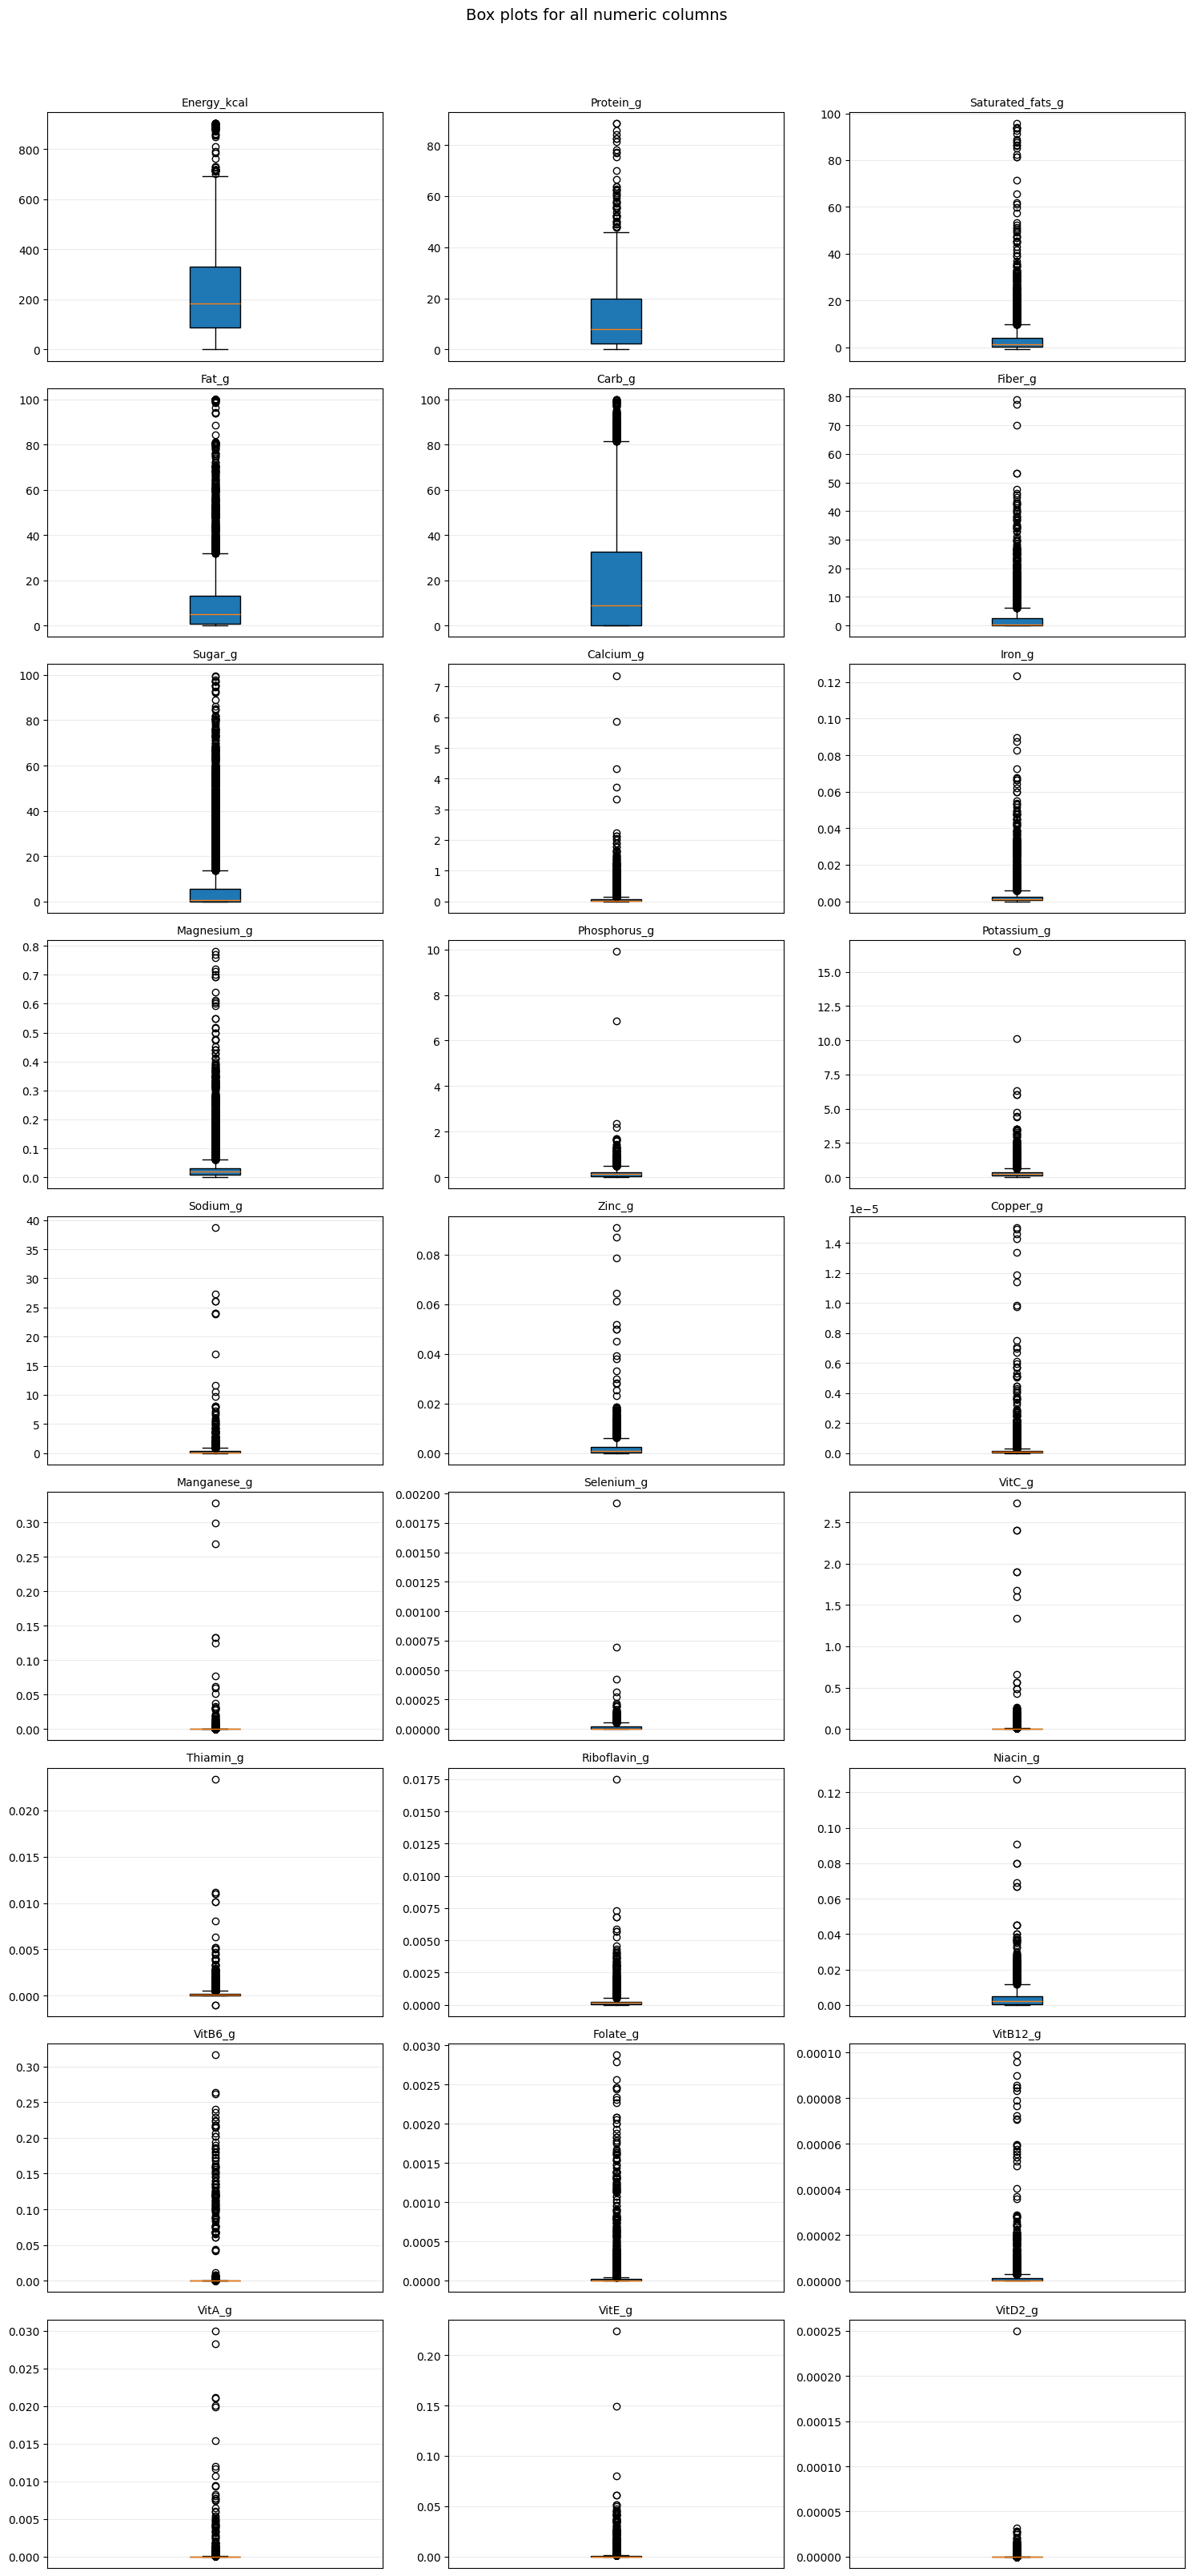

In [39]:
import math
import matplotlib.pyplot as plt

# Box plots for all numeric columns
numeric_data = df[num_cols]
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 3.5))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for ax, column in zip(axes, num_cols):
    series = numeric_data[column].dropna()
    ax.boxplot(series, vert=True, patch_artist=True)
    ax.set_title(column, fontsize=10)
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.25)

for ax in axes[len(num_cols):]:
    ax.axis("off")

fig.suptitle("Box plots for all numeric columns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.3. Pyramid charts
- Idea taken from Hynek Vaverka group's first presentation.
- We can see most foods recpect the minimum calory estimate:
$$\text{kcal} \ge 4\cdot \text{carbs} + 4\cdot \text{protein} + 9\cdot \text{fat} + 7\cdot \text{alcohol}$$
- However, some foods are in forbidden regions of the graphs (a food can't have 100 grams of carbs but 0 calories).

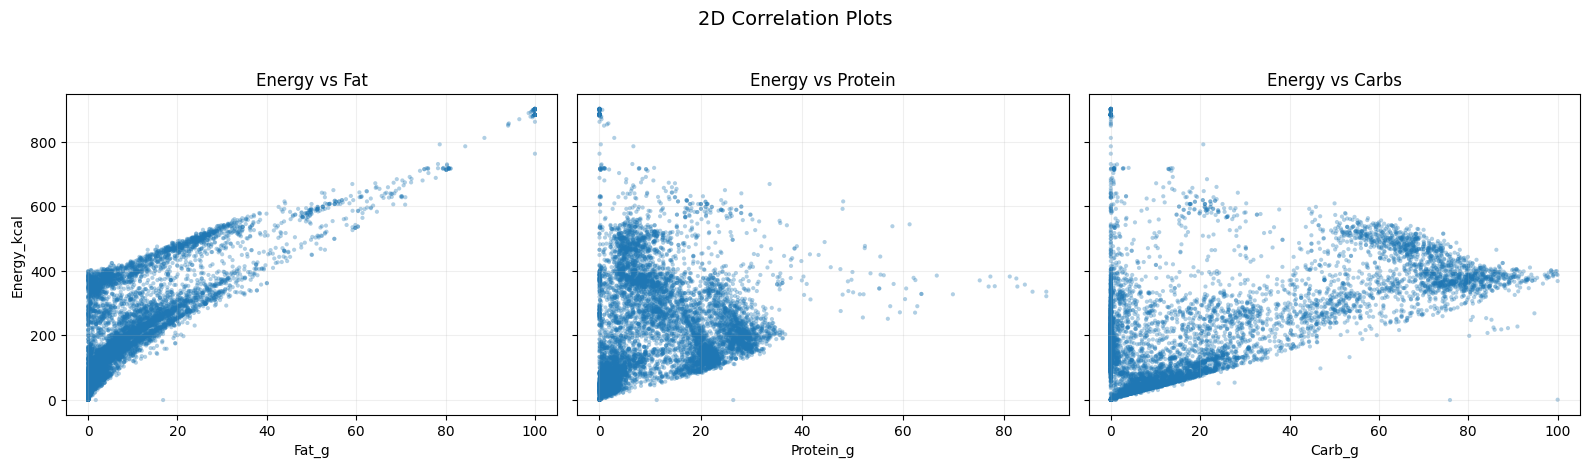

In [40]:
import matplotlib.pyplot as plt

# Simple 2D plots for Energy vs macronutrients (pyramid-like patterns)
pairs = [
    ("Fat_g", "Energy vs Fat"),
    ("Protein_g", "Energy vs Protein"),
    ("Carb_g", "Energy vs Carbs"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, (x_col, title) in zip(axes, pairs):
    plot_df = df[[x_col, "Energy_kcal"]].copy()
    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df["Energy_kcal"] = pd.to_numeric(plot_df["Energy_kcal"], errors="coerce")
    plot_df = plot_df.dropna()

    ax.scatter(
        plot_df[x_col],
        plot_df["Energy_kcal"],
        s=9,
        alpha=0.35,
        edgecolors="none"
    )
    ax.set_xlabel(x_col)
    ax.set_title(title)
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Energy_kcal")
fig.suptitle("2D Correlation Plots", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 1.4. Feature Correlation

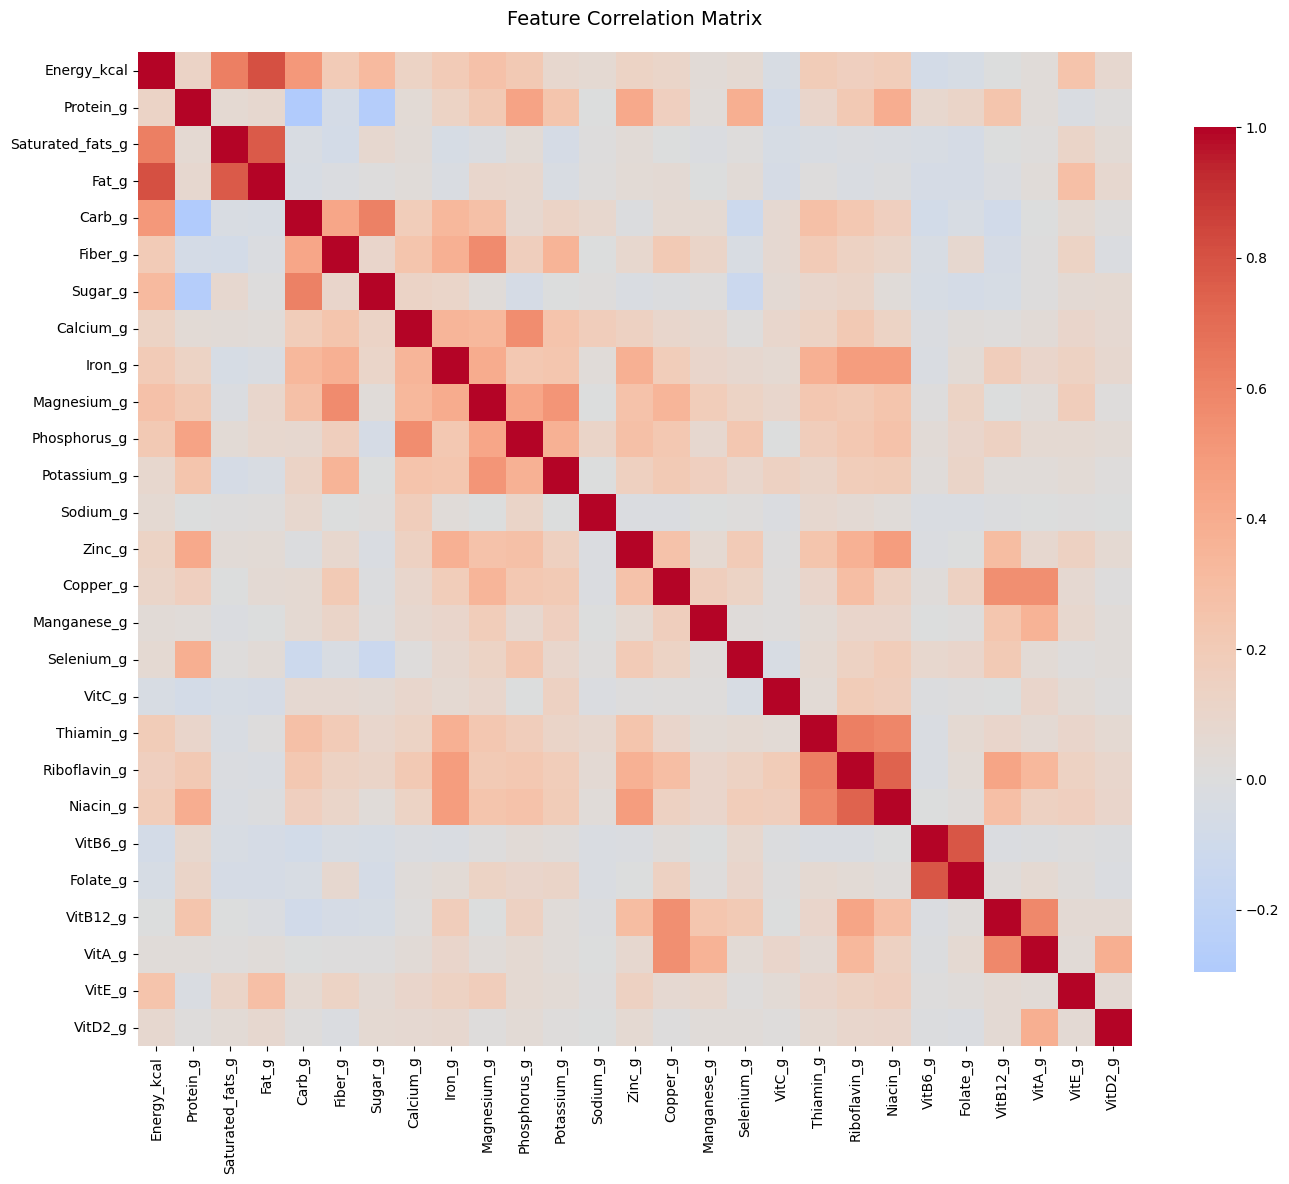

Highly correlated pairs (>0.95): 0


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df[num_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (>0.95)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f"Highly correlated pairs (>0.95): {len(high_corr_pairs)}")
for col1, col2, val in high_corr_pairs[:5]:
    print(f"  {col1} <-> {col2}: {val:.3f}")

### 1.5. 3D PCA Scatter (Nutrients, Minerals, Vitamins)

In [42]:
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# Categorize features
nutrients = [c for c in num_cols if any(x in c.lower() for x in ['energy', 'protein', 'fat', 'carb', 'fiber', 'sugar'])]
minerals = [c for c in num_cols if any(x in c.lower() for x in ['calcium', 'iron', 'magnesium', 'phosphorus', 'potassium', 'sodium', 'zinc', 'copper', 'manganese', 'selenium'])]
vitamins = [c for c in num_cols if any(x in c.lower() for x in ['vit', 'thiamin', 'riboflavin', 'niacin', 'folate'])]

print(f"Nutrients: {len(nutrients)}, Minerals: {len(minerals)}, Vitamins: {len(vitamins)}")

# Apply PCA to each group (1 component each)
pca_nut = PCA(n_components=1).fit_transform(df[nutrients]).flatten()
pca_min = PCA(n_components=1).fit_transform(df[minerals]).flatten()
pca_vit = PCA(n_components=1).fit_transform(df[vitamins]).flatten()

# Remove 99th percentile outliers for better visibility
p99_nut = np.percentile(np.abs(pca_nut), 99)
p99_min = np.percentile(np.abs(pca_min), 99)
p99_vit = np.percentile(np.abs(pca_vit), 99)

mask = (np.abs(pca_nut) <= p99_nut) & (np.abs(pca_min) <= p99_min) & (np.abs(pca_vit) <= p99_vit)
pca_nut_filt = pca_nut[mask]
pca_min_filt = pca_min[mask]
pca_vit_filt = pca_vit[mask]

print(f"Removed {(~mask).sum()} outliers (99th percentile), kept {mask.sum()} points")

# Interactive 3D scatter with Plotly
fig = go.Figure(data=[go.Scatter3d(
    x=pca_nut_filt,
    y=pca_min_filt,
    z=pca_vit_filt,
    mode='markers',
    marker=dict(
        size=4,
        color=pca_nut_filt,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Nutrient PC1')
    ),
    text=[f'Nut: {n:.2f}<br>Min: {m:.2f}<br>Vit: {v:.2f}' for n, m, v in zip(pca_nut_filt, pca_min_filt, pca_vit_filt)],
    hoverinfo='text'
)])

fig.update_layout(
    title='3D PCA Scatter: Nutrients vs Minerals vs Vitamins (Interactive)',
    scene=dict(
        xaxis_title='Nutrients (PC1)',
        yaxis_title='Minerals (PC1)',
        zaxis_title='Vitamins (PC1)',
    ),
    width=1000,
    height=800
)

fig

Nutrients: 7, Minerals: 10, Vitamins: 10
Removed 278 outliers (99th percentile), kept 8935 points


# 2. Preprocessing
In addition to the issues above, we will also explore the impact of using the log-transform on some highly skewd columns. We will compare the clustering results on both transformed and not transformed columns. Additionally, we will use RobustScaler, as it is *\*drumroll\**, Robust (to outliers). 

### 2.1. Outliers
- Clamp negative values
- Use the nutrient equation to remove invalid rows

In [60]:
# Start with numeric features, drop ID columns
X = df.select_dtypes(include="number").drop(columns=["NDB_No"], errors="ignore").copy()
print(f"Initial shape: {X.shape}")

# Clamp negative values to 0
neg_count = int((X < 0).sum().sum())
X = X.clip(lower=0)
print(f"Clamped {neg_count} negative values to 0")

# Remove rows violating the energy equation: kcal >= 4*carbs + 4*protein + 9*fat + 7*alcohol
# Calculate minimum required energy
min_energy = (4 * X['Carb_g'] + 4 * X['Protein_g'] + 9 * X['Fat_g']) / 1.2

# Keep only rows where observed energy >= minimum required energy
mask = X['Energy_kcal'] >= min_energy
removed = int((~mask).sum())

print(f"Removed {removed} rows violating energy equation (Energy < 4*Carb + 4*Protein + 9*Fat)")

Initial shape: (9213, 27)
Clamped 10 negative values to 0
Removed 348 rows violating energy equation (Energy < 4*Carb + 4*Protein + 9*Fat)


### 2.2. Feature Engineering
- Nutrient ratios
- Mineral and Vitamin densities

In [61]:
# Create engineered features on the cleaned data
X_eng = X.copy()

# Nutrient ratios
if 'Energy_kcal' in X_eng.columns and 'Protein_g' in X_eng.columns:
    X_eng['Protein_per_kcal'] = X_eng['Protein_g'] / (X_eng['Energy_kcal'] + 1e-8)
if 'Fiber_g' in X_eng.columns and 'Carb_g' in X_eng.columns:
    X_eng['Fiber_Carb_ratio'] = X_eng['Fiber_g'] / (X_eng['Carb_g'] + 1e-8)
if 'Saturated_fats_g' in X_eng.columns and 'Fat_g' in X_eng.columns:
    X_eng['Saturated_fat_ratio'] = X_eng['Saturated_fats_g'] / (X_eng['Fat_g'] + 1e-8)

# Mineral and vitamin densities
minerals = [c for c in X_eng.columns if any(x in c.lower() for x in ['calcium', 'iron', 'magnesium', 'phosphorus', 'potassium', 'sodium', 'zinc', 'copper', 'manganese', 'selenium'])]
vitamins = [c for c in X_eng.columns if any(x in c.lower() for x in ['vit', 'thiamin', 'riboflavin', 'niacin', 'folate'])]
if minerals:
    X_eng['Mineral_density'] = X_eng[minerals].sum(axis=1)
if vitamins:
    X_eng['Vitamin_density'] = X_eng[vitamins].sum(axis=1)

engineered_cols = [c for c in X_eng.columns if c not in X.columns]
print(f"Created {len(engineered_cols)} engineered features: {engineered_cols}")
print(f"Total features: {X_eng.shape[1]}")

Created 5 engineered features: ['Protein_per_kcal', 'Fiber_Carb_ratio', 'Saturated_fat_ratio', 'Mineral_density', 'Vitamin_density']
Total features: 32


### 2.3. Duplicate Dataset with Log1p Transform

In [67]:
# Create log1p-transformed copy (on skewed columns)
X_log1p = X_eng.copy()

# Identify columns with high positive skew
skew_threshold = 10.0
skew_vals = X_log1p.skew(numeric_only=True)
log_cols = skew_vals[skew_vals > skew_threshold].index.tolist()

if log_cols:
    X_log1p[log_cols] = np.log1p(X_log1p[log_cols])
    print(f"Applied log1p to {len(log_cols)} skewed columns")
else:
    print("No columns above skew threshold")

print(f"Shape: {X_log1p.shape}")

Applied log1p to 19 skewed columns
Shape: (9213, 32)


### 2.4. Robust Scaler

In [68]:
from sklearn.preprocessing import RobustScaler

# Scale both variants with RobustScaler
scaler_nonlog = RobustScaler()
X_nonlog_scaled = pd.DataFrame(
    scaler_nonlog.fit_transform(X_eng),
    index=X_eng.index,
    columns=X_eng.columns,
)

scaler_log1p = RobustScaler()
X_log1p_scaled = pd.DataFrame(
    scaler_log1p.fit_transform(X_log1p),
    index=X_log1p.index,
    columns=X_log1p.columns,
)

# Create standalone datasets dict
datasets = {
    "nonlog": X_nonlog_scaled,
    "log1p": X_log1p_scaled,
}

# Verify alignment
print(f"nonlog shape: {datasets['nonlog'].shape}")
print(f"log1p shape:  {datasets['log1p'].shape}")
print(f"Columns match: {list(datasets['nonlog'].columns) == list(datasets['log1p'].columns)}")
print(f"Index match: {datasets['nonlog'].index.equals(datasets['log1p'].index)}")
print(f"\nDatasets ready: {list(datasets.keys())}")

nonlog shape: (9213, 32)
log1p shape:  (9213, 32)
Columns match: True
Index match: True

Datasets ready: ['nonlog', 'log1p']


# 3. Models

### 3.1. Baseline - KMeans

In [71]:
from sklearn.metrics import silhouette_score
import itertools
import warnings
warnings.filterwarnings('ignore')

# Define parameter grid for KMeans
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6, 7, 8],
    'init': ['k-means++', 'random'],
    'n_init': [10, 30],
}

# Store results for both datasets
grid_results = {}

for variant, X_data in datasets.items():
    print(f"\n{'='*60}")
    print(f"Grid Search for {variant.upper()} dataset")
    print(f"Shape: {X_data.shape}")
    print(f"{'='*60}")
    
    results_list = []
    
    # Generate all parameter combinations
    param_combinations = list(itertools.product(
        param_grid['n_clusters'],
        param_grid['init'],
        param_grid['n_init']
    ))
    
    print(f"Testing {len(param_combinations)} parameter combinations...\n")
    
    best_score = -1
    best_params = None
    
    for n_clusters, init, n_init in param_combinations:
        # Fit KMeans
        km = KMeans(
            n_clusters=n_clusters,
            init=init,
            n_init=n_init,
            random_state=42
        )
        km.fit(X_data)
        
        # Compute silhouette score
        score = silhouette_score(X_data, km.labels_)
        
        results_list.append({
            'n_clusters': n_clusters,
            'init': init,
            'n_init': n_init,
            'silhouette_score': score,
            'inertia': km.inertia_,
        })
        
        # Track best
        if score > best_score:
            best_score = score
            best_params = {'n_clusters': n_clusters, 'init': init, 'n_init': n_init}
    
    # Convert to dataframe
    results_df = pd.DataFrame(results_list)
    grid_results[variant] = {
        'results_df': results_df,
        'best_params': best_params,
        'best_score': best_score,
    }
    
    print(f"Best parameters: {best_params}")
    print(f"Best silhouette score: {best_score:.4f}\n")
    print("Top 10 configurations:")
    print(results_df.sort_values('silhouette_score', ascending=False).head(10).to_string(index=False))

# Comparison between datasets
print(f"\n{'='*60}")
print("COMPARISON SUMMARY")
print(f"{'='*60}")
comparison_data = []
for variant, results in grid_results.items():
    comparison_data.append({
        'Dataset': variant.upper(),
        'Best n_clusters': results['best_params']['n_clusters'],
        'Best init': results['best_params']['init'],
        'Best n_init': results['best_params']['n_init'],
        'Best silhouette': f"{results['best_score']:.4f}",
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


Grid Search for NONLOG dataset
Shape: (9213, 32)
Testing 28 parameter combinations...

Best parameters: {'n_clusters': 2, 'init': 'random', 'n_init': 10}
Best silhouette score: 0.9998

Top 10 configurations:
 n_clusters      init  n_init  silhouette_score      inertia
          2    random      30          0.999798 1.513638e+20
          2    random      10          0.999798 1.513638e+20
          3 k-means++      30          0.999777 3.966046e+16
          3 k-means++      10          0.999777 3.966046e+16
          3    random      10          0.999774 1.513241e+20
          3    random      30          0.999774 1.513241e+20
          2 k-means++      10          0.999761 1.691367e+20
          2 k-means++      30          0.999761 1.691367e+20
          4 k-means++      10          0.999756 1.047735e+13
          4 k-means++      30          0.999756 1.047735e+13

Grid Search for LOG1P dataset
Shape: (9213, 32)
Testing 28 parameter combinations...

Best parameters: {'n_clusters': 3


BEST CLUSTERING: NONLOG

Parameters: n_clusters=2, init=random, n_init=10
Overall silhouette score: 0.9998

Cluster Statistics:
Cluster   Size      Pct       Avg Silhouette      
--------------------------------------------------
0         2         0.0       %0.0876              
1         9211      100.0     %1.0000              

BEST CLUSTERING: LOG1P

Parameters: n_clusters=3, init=random, n_init=10
Overall silhouette score: 0.9430

Cluster Statistics:
Cluster   Size      Pct       Avg Silhouette      
--------------------------------------------------
0         9085      98.6      %0.9493              
1         18        0.2       %0.1938              
2         110       1.2       %0.5489              


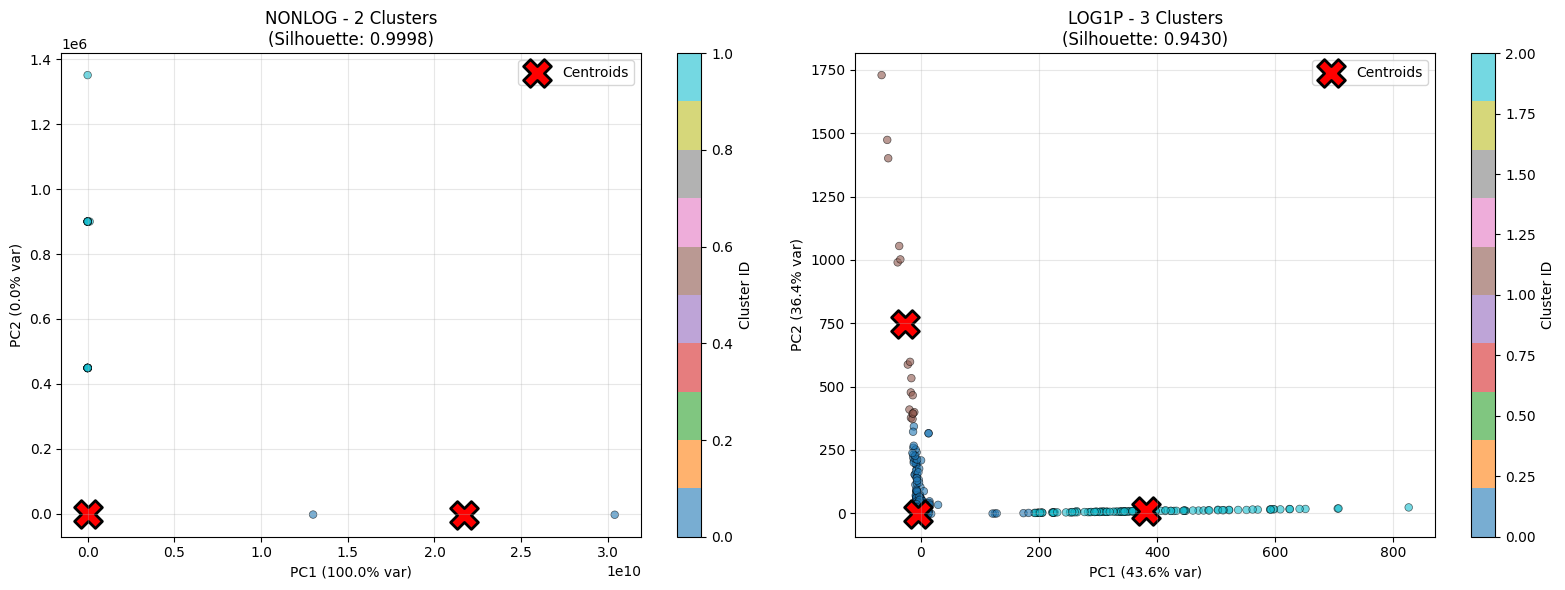


FINAL COMPARISON

NONLOG:
  Clusters: 2
  Silhouette Score: 0.9998
  Explained Variance (PC1+PC2): 100.0%

LOG1P:
  Clusters: 3
  Silhouette Score: 0.9430
  Explained Variance (PC1+PC2): 80.0%


In [ ]:
from sklearn.metrics import silhouette_samples
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Fit best KMeans models and visualize
best_models = {}

for variant, X_data in datasets.items():
    print(f"\n{'='*60}")
    print(f"BEST CLUSTERING: {variant.upper()}")
    print(f"{'='*60}")
    
    # Get best parameters and fit
    best_params = grid_results[variant]['best_params']
    km_best = KMeans(
        n_clusters=best_params['n_clusters'],
        init=best_params['init'],
        n_init=best_params['n_init'],
        random_state=42
    )
    labels = km_best.fit_predict(X_data)
    best_models[variant] = {
        'model': km_best,
        'labels': labels,
        'params': best_params
    }
    
    # Compute silhouette scores per sample
    silhouette_vals = silhouette_samples(X_data, labels)
    
    # Print cluster statistics
    print(f"\nParameters: n_clusters={best_params['n_clusters']}, init={best_params['init']}, n_init={best_params['n_init']}")
    print(f"Overall silhouette score: {grid_results[variant]['best_score']:.4f}")
    print(f"\nCluster Statistics:")
    print(f"{'Cluster':<10}{'Size':<10}{'Pct':<10}{'Avg Silhouette':<20}")
    print("-" * 50)
    
    for cluster_id in range(best_params['n_clusters']):
        cluster_mask = labels == cluster_id
        cluster_size = cluster_mask.sum()
        cluster_pct = 100 * cluster_size / len(labels)
        avg_silhouette = silhouette_vals[cluster_mask].mean()
        print(f"{cluster_id:<10}{cluster_size:<10}{cluster_pct:<10.1f}%{avg_silhouette:<20.4f}")

# Plot best clusterings using PCA projection
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (variant, X_data) in enumerate(datasets.items()):
    ax = axes[idx]
    
    # PCA for 2D visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_data)
    
    labels = best_models[variant]['labels']
    params = best_models[variant]['params']
    
    # Plot clusters
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', 
                        s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Plot centroids in PCA space
    centroids_pca = pca.transform(best_models[variant]['model'].cluster_centers_)
    ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', 
              s=400, edgecolors='black', linewidth=2, label='Centroids')
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
    ax.set_title(f"{variant.upper()} - {params['n_clusters']} Clusters\n(Silhouette: {grid_results[variant]['best_score']:.4f})")
    ax.grid(alpha=0.3)
    ax.legend()
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Cluster ID')

plt.tight_layout()
plt.show()

# Summary comparison
print(f"\n{'='*60}")
print("FINAL COMPARISON")
print(f"{'='*60}")
for variant in datasets.keys():
    params = best_models[variant]['params']
    score = grid_results[variant]['best_score']
    print(f"\n{variant.upper()}:")
    print(f"  Clusters: {params['n_clusters']}")
    print(f"  Silhouette Score: {score:.4f}")
    print(f"  Explained Variance (PC1+PC2): {(PCA(n_components=2).fit(datasets[variant]).explained_variance_ratio_.sum()):.1%}")

In [73]:
# Expanded Grid Search with more comprehensive parameter space
param_grid_expanded = {
    'n_clusters': list(range(2, 16)),  # 2-15 clusters
    'init': ['k-means++', 'random'],
    'n_init': [10, 30, 50],
    'max_iter': [300, 500],
}

print(f"Total combinations to test: {len(param_grid_expanded['n_clusters']) * len(param_grid_expanded['init']) * len(param_grid_expanded['n_init']) * len(param_grid_expanded['max_iter'])}")

# Store all results
all_models_results = {}

for variant, X_data in datasets.items():
    print(f"\n{'='*80}")
    print(f"EXPANDED GRID SEARCH: {variant.upper()}")
    print(f"{'='*80}")
    
    all_results = []
    best_score = -1
    best_model_data = None
    
    total_configs = (len(param_grid_expanded['n_clusters']) * 
                     len(param_grid_expanded['init']) * 
                     len(param_grid_expanded['n_init']) *
                     len(param_grid_expanded['max_iter']))
    
    config_count = 0
    for n_clusters in param_grid_expanded['n_clusters']:
        for init in param_grid_expanded['init']:
            for n_init in param_grid_expanded['n_init']:
                for max_iter in param_grid_expanded['max_iter']:
                    config_count += 1
                    if config_count % 50 == 0:
                        print(f"Progress: {config_count}/{total_configs}", end='\r')
                    
                    km = KMeans(
                        n_clusters=n_clusters,
                        init=init,
                        n_init=n_init,
                        max_iter=max_iter,
                        random_state=42
                    )
                    labels = km.fit_predict(X_data)
                    score = silhouette_score(X_data, labels)
                    
                    # Calculate cluster sizes and percentages
                    unique, counts = np.unique(labels, return_counts=True)
                    cluster_sizes = dict(zip(unique, counts))
                    cluster_pcts = {k: 100*v/len(labels) for k, v in cluster_sizes.items()}
                    
                    # Check balance: how evenly distributed are clusters
                    pct_vals = list(cluster_pcts.values())
                    max_cluster_pct = max(pct_vals)
                    min_cluster_pct = min(pct_vals)
                    cluster_balance = 1 - (max_cluster_pct - min_cluster_pct) / 100
                    
                    all_results.append({
                        'n_clusters': n_clusters,
                        'init': init,
                        'n_init': n_init,
                        'max_iter': max_iter,
                        'silhouette_score': score,
                        'inertia': km.inertia_,
                        'max_cluster_pct': max_cluster_pct,
                        'min_cluster_pct': min_cluster_pct,
                        'cluster_balance': cluster_balance,
                        'labels': labels,
                        'model': km,
                    })
                    
                    if score > best_score:
                        best_score = score
                        best_model_data = all_results[-1]
    
    all_models_results[variant] = pd.DataFrame([{k: v for k, v in item.items() if k not in ['labels', 'model']} for item in all_results])
    all_models_results[variant]['model_obj'] = [item['model'] for item in all_results]
    all_models_results[variant]['labels'] = [item['labels'] for item in all_results]
    
    print(f"\nCompleted {total_configs} configurations")
    print(f"\nTop 15 by Silhouette Score:")
    print(all_models_results[variant].nlargest(15, 'silhouette_score')[['n_clusters', 'init', 'n_init', 'max_iter', 'silhouette_score', 'max_cluster_pct', 'cluster_balance']].to_string(index=False))
    
    print(f"\n\nTop 15 by Cluster Balance (most even distribution):")
    print(all_models_results[variant].nlargest(15, 'cluster_balance')[['n_clusters', 'init', 'n_init', 'silhouette_score', 'max_cluster_pct', 'cluster_balance']].to_string(index=False))

Total combinations to test: 168

EXPANDED GRID SEARCH: NONLOG
Progress: 150/168
Completed 168 configurations

Top 15 by Silhouette Score:
 n_clusters      init  n_init  max_iter  silhouette_score  max_cluster_pct  cluster_balance
          2    random      10       300          0.999798        99.978292         0.000434
          2    random      10       500          0.999798        99.978292         0.000434
          2    random      30       300          0.999798        99.978292         0.000434
          2    random      30       500          0.999798        99.978292         0.000434
          2    random      50       300          0.999798        99.978292         0.000434
          2    random      50       500          0.999798        99.978292         0.000434
          3 k-means++      10       300          0.999777        99.978292         0.000326
          3 k-means++      10       500          0.999777        99.978292         0.000326
          3 k-means++      30     

### 3.2. Hierarchical Agglomerative Clustering (HAC)

### 3.3. DBSCAN (Eva)

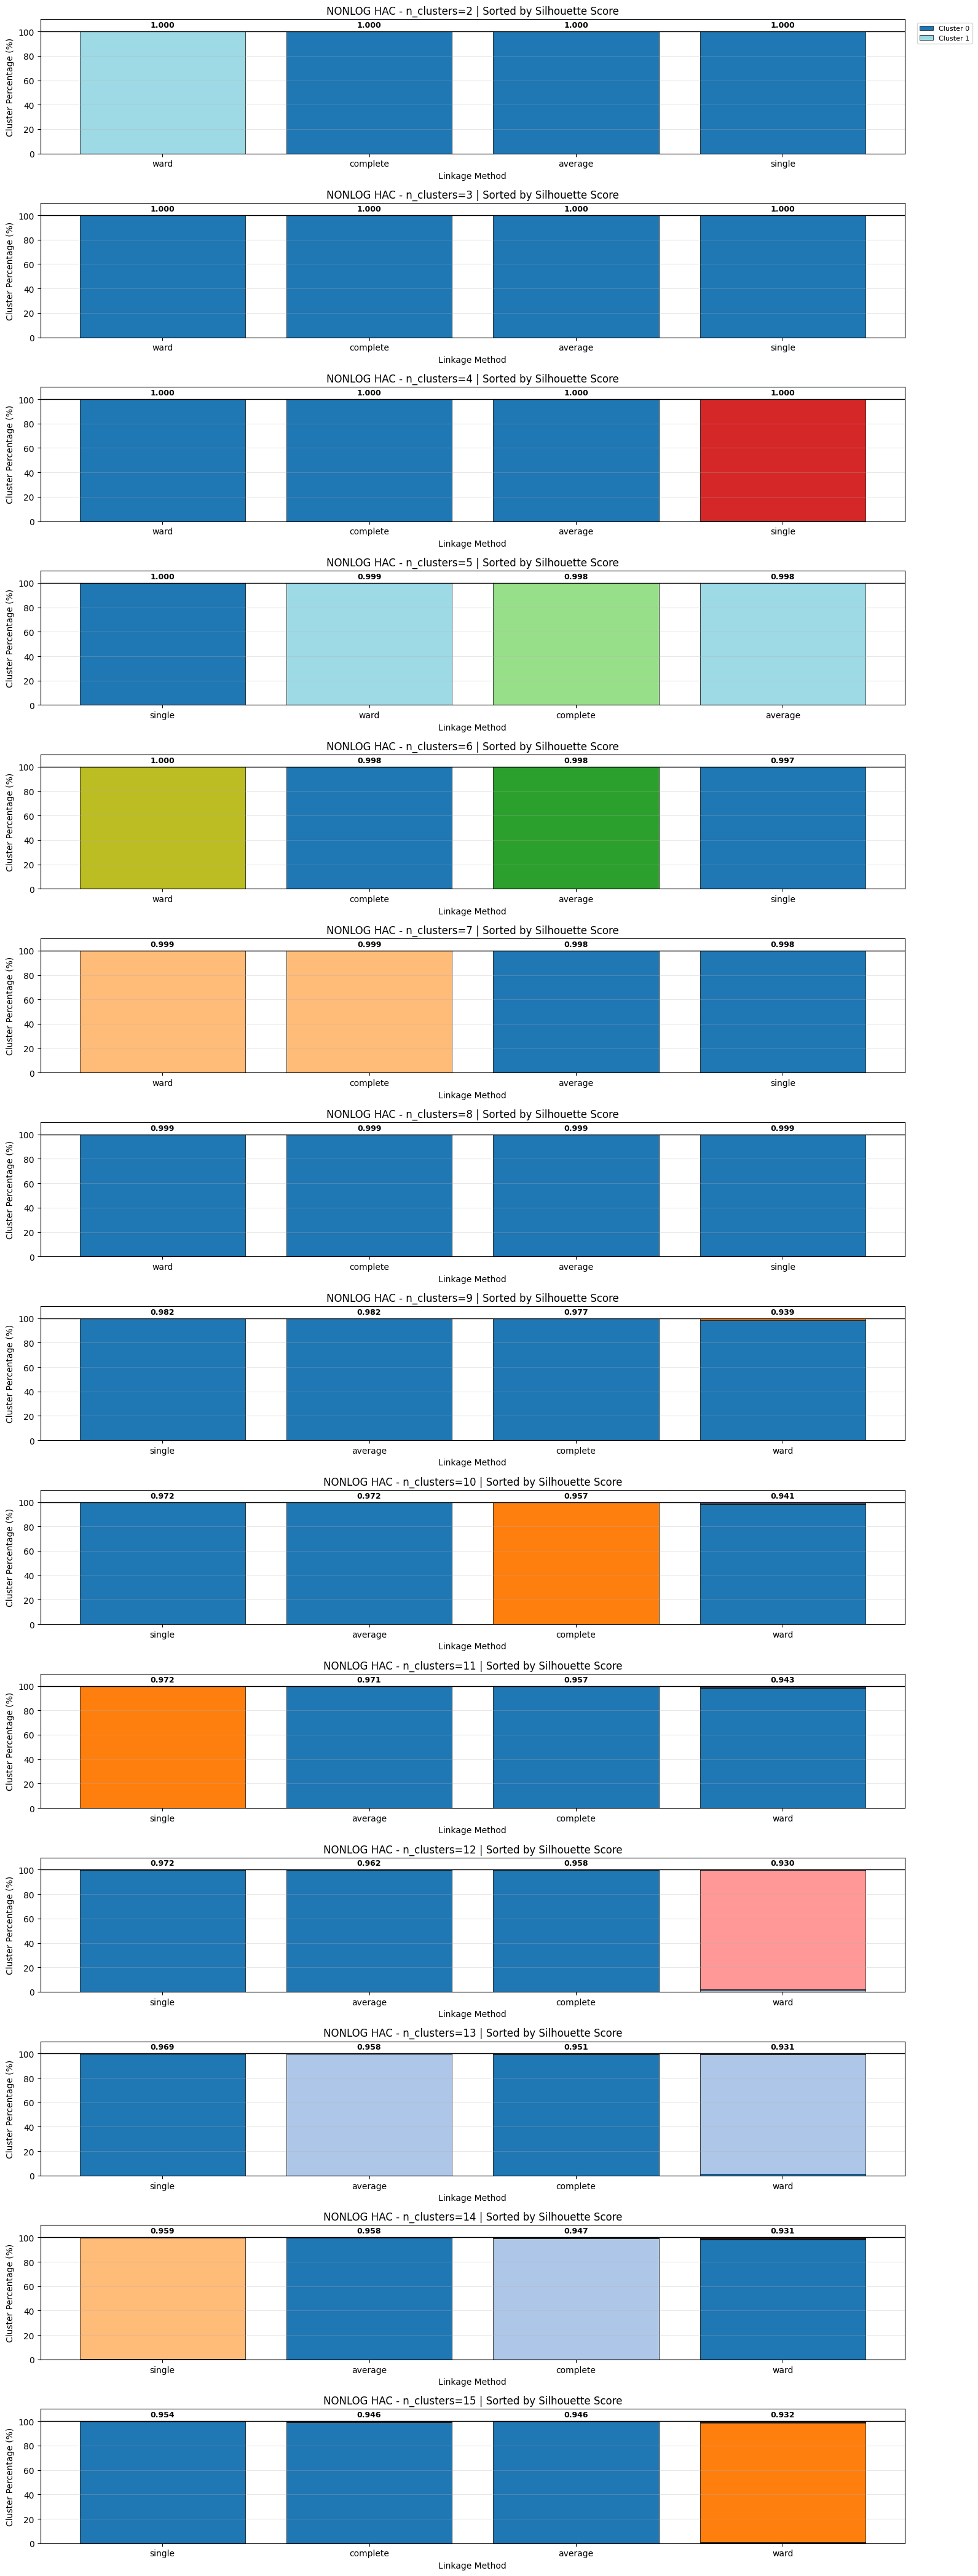

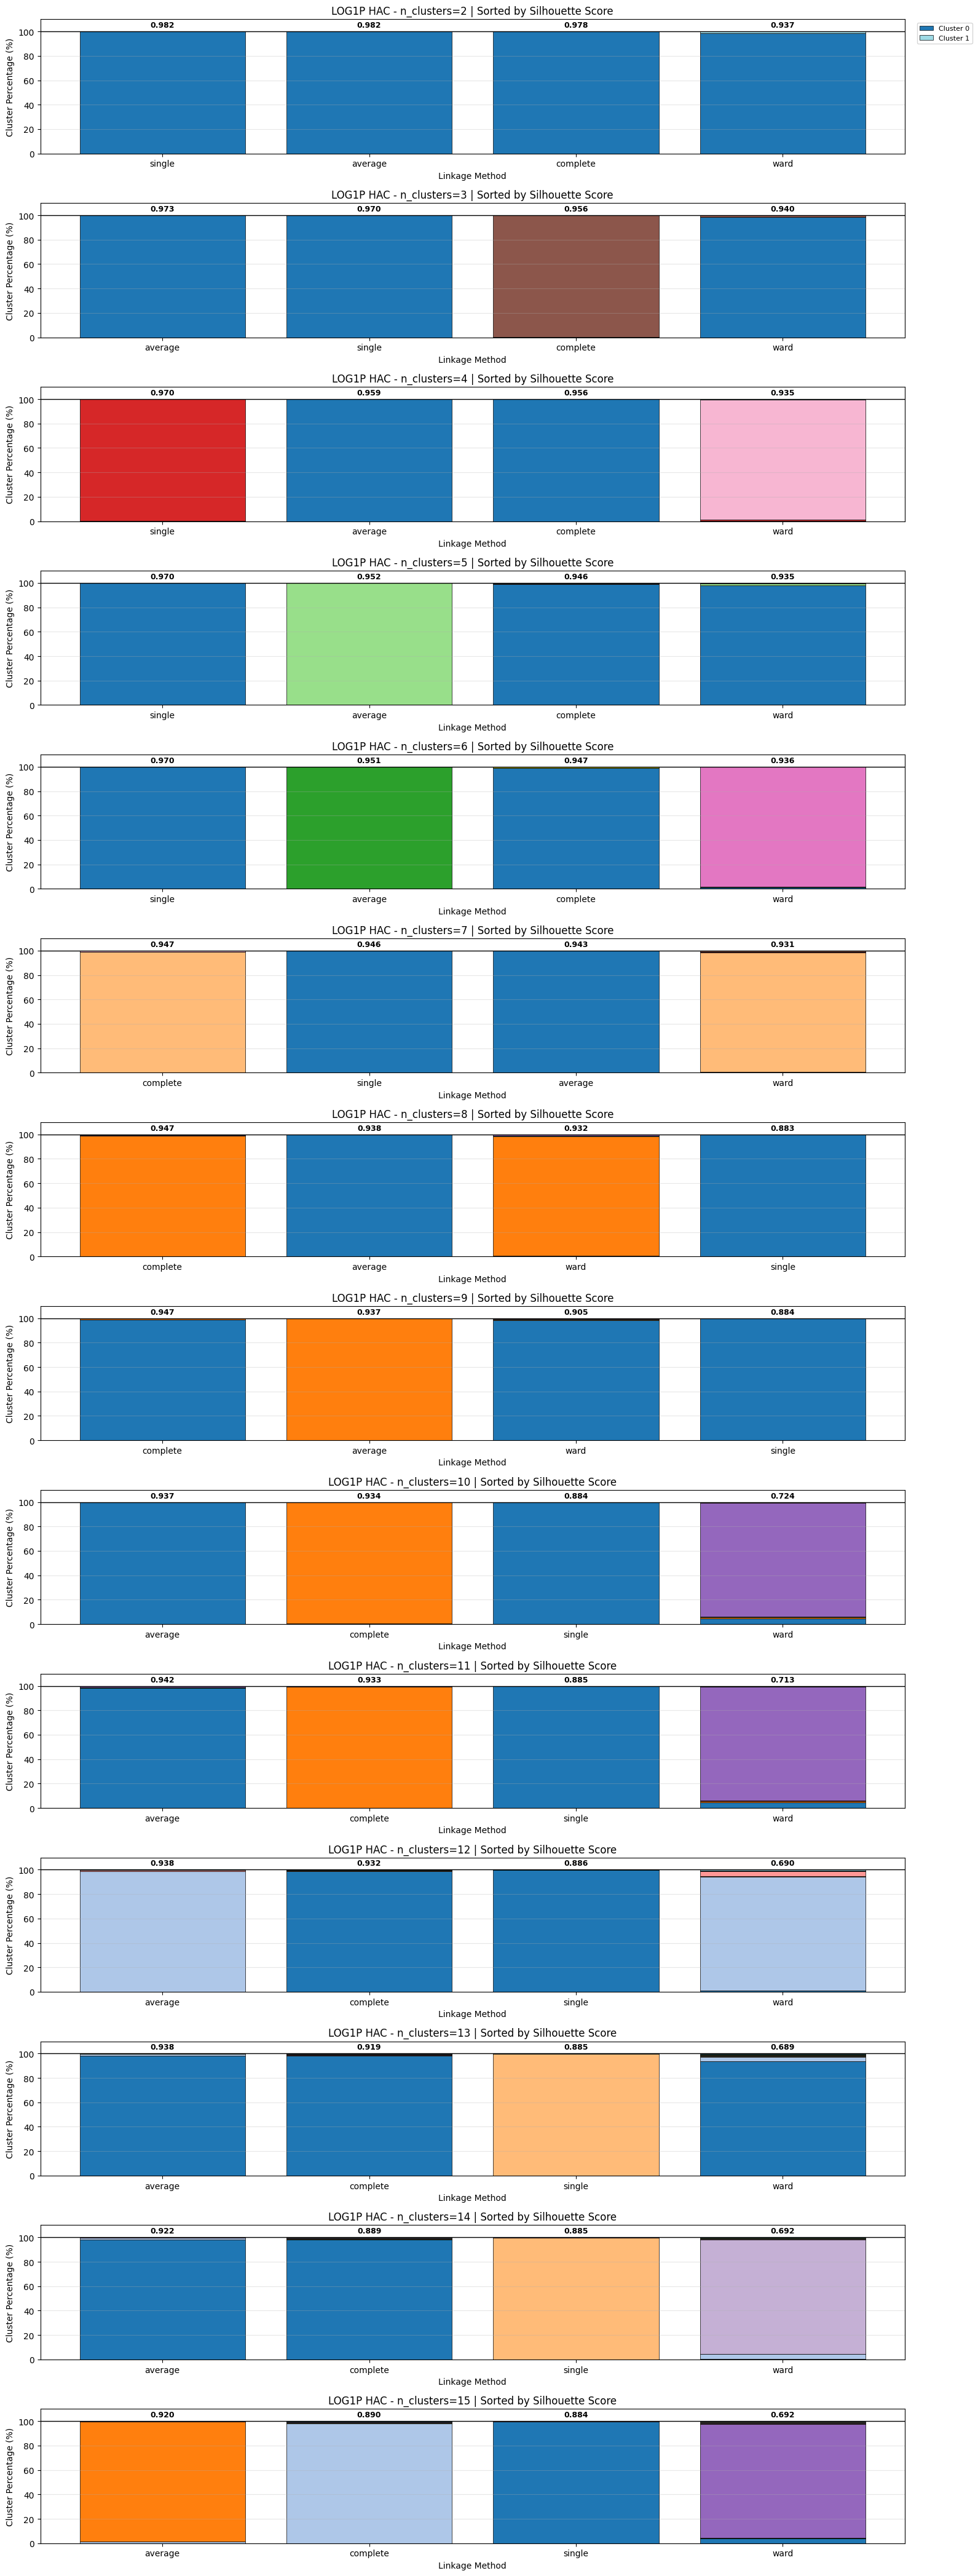


COMPARISON: KMeans vs HAC

NONLOG:

  KMeans - Best Silhouette:
    n_clusters=2, score=0.9998, max_cluster_pct=100.0%

  KMeans - Best Balance:
    n_clusters=15, score=0.1010, balance=0.5520, max_cluster_pct=44.8%

  HAC - Best Silhouette:
    n_clusters=2, linkage=ward, score=0.9998, max_cluster_pct=100.0%

  HAC - Best Balance:
    n_clusters=15, linkage=ward, score=0.9322, balance=0.0214, max_cluster_pct=97.9%

LOG1P:

  KMeans - Best Silhouette:
    n_clusters=3, score=0.9430, max_cluster_pct=98.6%

  KMeans - Best Balance:
    n_clusters=15, score=0.4761, balance=0.1837, max_cluster_pct=81.7%

  HAC - Best Silhouette:
    n_clusters=2, linkage=average, score=0.9819, max_cluster_pct=100.0%

  HAC - Best Balance:
    n_clusters=14, linkage=ward, score=0.6916, balance=0.0660, max_cluster_pct=93.4%


In [77]:
# Visualization of HAC models - Grid showing cluster distributions
import matplotlib.pyplot as plt

for variant, X_data in datasets.items():
    results_df = hac_results_all[variant]
    
    # Get unique n_clusters values
    n_clusters_vals = sorted(results_df['n_clusters'].unique())
    
    # Create subplots: one for each n_clusters
    fig, axes = plt.subplots(len(n_clusters_vals), 1, figsize=(16, 3*len(n_clusters_vals)))
    if len(n_clusters_vals) == 1:
        axes = [axes]
    
    for idx, n_clust in enumerate(n_clusters_vals):
        ax = axes[idx]
        
        # Get all configurations for this n_clusters
        subset = results_df[results_df['n_clusters'] == n_clust].copy()
        subset = subset.sort_values('silhouette_score', ascending=False)
        
        config_labels = [row['linkage'] for _, row in subset.iterrows()]
        silhouette_scores = subset['silhouette_score'].values
        
        # Create color map for clusters
        colors = plt.cm.tab20(np.linspace(0, 1, n_clust))
        
        # Get cluster percentages for each config
        cluster_data = []
        for idx_row, (_, row) in enumerate(subset.iterrows()):
            labels = row['labels']
            _, counts = np.unique(labels, return_counts=True)
            pcts = 100 * counts / len(labels)
            # Pad with zeros if needed
            pcts_padded = np.zeros(n_clust)
            pcts_padded[:len(pcts)] = pcts
            cluster_data.append(pcts_padded)
        
        cluster_data = np.array(cluster_data)
        
        # Create stacked bar chart
        x_pos = np.arange(len(config_labels))
        bottom = np.zeros(len(config_labels))
        
        for cluster_id in range(n_clust):
            ax.bar(x_pos, cluster_data[:, cluster_id], bottom=bottom, 
                   label=f'Cluster {cluster_id}', color=colors[cluster_id], edgecolor='black', linewidth=0.5)
            bottom += cluster_data[:, cluster_id]
        
        # Overlay silhouette scores as text
        for i, (score, label) in enumerate(zip(silhouette_scores, config_labels)):
            ax.text(i, 102, f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_ylabel('Cluster Percentage (%)')
        ax.set_xlabel('Linkage Method')
        ax.set_title(f"{variant.upper()} HAC - n_clusters={n_clust} | Sorted by Silhouette Score")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(config_labels, rotation=0, ha='center', fontsize=10)
        ax.set_ylim([0, 110])
        ax.axhline(y=100, color='black', linestyle='-', linewidth=1)
        ax.grid(axis='y', alpha=0.3)
        
        if idx == 0 and n_clust <= 8:
            ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, ncol=1)
    
    plt.tight_layout()
    plt.show()

# Summary comparison: HAC vs KMeans
print(f"\n{'='*90}")
print("COMPARISON: KMeans vs HAC")
print(f"{'='*90}")

for variant in datasets.keys():
    print(f"\n{variant.upper()}:")
    
    # KMeans best
    kmeans_df = all_models_results[variant]
    best_kmeans_sil = kmeans_df.nlargest(1, 'silhouette_score').iloc[0]
    best_kmeans_bal = kmeans_df.nlargest(1, 'cluster_balance').iloc[0]
    
    # HAC best
    hac_df = hac_results_all[variant]
    best_hac_sil = hac_df.nlargest(1, 'silhouette_score').iloc[0]
    best_hac_bal = hac_df.nlargest(1, 'cluster_balance').iloc[0]
    
    print(f"\n  KMeans - Best Silhouette:")
    print(f"    n_clusters={int(best_kmeans_sil['n_clusters'])}, score={best_kmeans_sil['silhouette_score']:.4f}, max_cluster_pct={best_kmeans_sil['max_cluster_pct']:.1f}%")
    
    print(f"\n  KMeans - Best Balance:")
    print(f"    n_clusters={int(best_kmeans_bal['n_clusters'])}, score={best_kmeans_bal['silhouette_score']:.4f}, balance={best_kmeans_bal['cluster_balance']:.4f}, max_cluster_pct={best_kmeans_bal['max_cluster_pct']:.1f}%")
    
    print(f"\n  HAC - Best Silhouette:")
    print(f"    n_clusters={int(best_hac_sil['n_clusters'])}, linkage={best_hac_sil['linkage']}, score={best_hac_sil['silhouette_score']:.4f}, max_cluster_pct={best_hac_sil['max_cluster_pct']:.1f}%")
    
    print(f"\n  HAC - Best Balance:")
    print(f"    n_clusters={int(best_hac_bal['n_clusters'])}, linkage={best_hac_bal['linkage']}, score={best_hac_bal['silhouette_score']:.4f}, balance={best_hac_bal['cluster_balance']:.4f}, max_cluster_pct={best_hac_bal['max_cluster_pct']:.1f}%")
    
    # Find balanced solutions (max cluster < 70%)
    balanced_mask = hac_df['max_cluster_pct'] < 70
    if balanced_mask.sum() > 0:
        best_balanced = hac_df[balanced_mask].nlargest(1, 'silhouette_score').iloc[0]
        print(f"\n  HAC - Best Balanced (<70% max cluster):")
        print(f"    n_clusters={int(best_balanced['n_clusters'])}, linkage={best_balanced['linkage']}, score={best_balanced['silhouette_score']:.4f}, max_cluster_pct={best_balanced['max_cluster_pct']:.1f}%")

In [ ]:
# Analysis: Find trade-off solutions with meaningful silhouette (>0.3) and balance constraints
print(f"\n{'='*90}")
print("TRADE-OFF ANALYSIS: Solutions with meaningful clustering (silhouette > 0.3, max_cluster < 80%)")
print(f"{'='*90}")

for variant in datasets.keys():
    print(f"\n{variant.upper()}:")
    
    # Analyze both KMeans and HAC
    for algo_name, results_df in [("KMeans", all_models_results[variant]), ("HAC", hac_results_all[variant])]:
        # Filter: silhouette > 0.3 AND max_cluster < 80%
        filtered = results_df[(results_df['silhouette_score'] > 0.3) & (results_df['max_cluster_pct'] < 80)].copy()
        
        if len(filtered) > 0:
            # Sort by cluster balance (higher is better) to show most balanced solutions
            top_balanced = filtered.nlargest(5, 'cluster_balance')[['n_clusters', 'silhouette_score', 'max_cluster_pct', 'min_cluster_pct', 'cluster_balance']]
            if algo_name == "HAC":
                top_balanced = filtered[['n_clusters', 'linkage', 'silhouette_score', 'max_cluster_pct', 'min_cluster_pct', 'cluster_balance']].nlargest(5, 'cluster_balance')
            
            print(f"\n  {algo_name} - Top 5 Balanced Solutions (silhouette > 0.3, max < 80%):")
            print(top_balanced.to_string(index=False))
        else:
            print(f"\n  {algo_name} - No solutions meet criteria (silhouette > 0.3, max < 80%)")
    
    # Summary: Can we achieve 50-60% max cluster with decent silhouette?
    for algo_name, results_df in [("KMeans", all_models_results[variant]), ("HAC", hac_results_all[variant])]:
        highly_balanced = results_df[results_df['max_cluster_pct'] < 60]
        if len(highly_balanced) > 0:
            best = highly_balanced.nlargest(1, 'silhouette_score').iloc[0]
            if algo_name == "KMeans":
                print(f"\n  {algo_name} - Best with max < 60%: n_clusters={int(best['n_clusters'])}, silhouette={best['silhouette_score']:.4f}, max={best['max_cluster_pct']:.1f}%")
            else:
                print(f"\n  {algo_name} - Best with max < 60%: n_clusters={int(best['n_clusters'])}, linkage={best['linkage']}, silhouette={best['silhouette_score']:.4f}, max={best['max_cluster_pct']:.1f}%")

In [76]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Grid search for HAC
hac_param_grid = {
    'n_clusters': list(range(2, 16)),  # 2-15 clusters
    'linkage': ['ward', 'complete', 'average', 'single'],
}

print(f"Total HAC combinations to test: {len(hac_param_grid['n_clusters']) * len(hac_param_grid['linkage'])}")

# Store HAC results
hac_results_all = {}

for variant, X_data in datasets.items():
    print(f"\n{'='*80}")
    print(f"HIERARCHICAL AGGLOMERATIVE CLUSTERING GRID SEARCH: {variant.upper()}")
    print(f"{'='*80}")
    
    hac_results_list = []
    best_score = -1
    best_config = None
    
    total_configs = len(hac_param_grid['n_clusters']) * len(hac_param_grid['linkage'])
    config_count = 0
    
    for n_clusters in hac_param_grid['n_clusters']:
        for linkage_method in hac_param_grid['linkage']:
            config_count += 1
            if config_count % 10 == 0:
                print(f"Progress: {config_count}/{total_configs}", end='\r')
            
            try:
                hac = AgglomerativeClustering(
                    n_clusters=n_clusters,
                    linkage=linkage_method,
                    metric='euclidean'
                )
                labels = hac.fit_predict(X_data)
                score = silhouette_score(X_data, labels)
                
                # Calculate cluster balance metrics
                unique, counts = np.unique(labels, return_counts=True)
                cluster_pcts = 100 * counts / len(labels)
                max_cluster_pct = cluster_pcts.max()
                min_cluster_pct = cluster_pcts.min()
                cluster_balance = 1 - (max_cluster_pct - min_cluster_pct) / 100
                
                hac_results_list.append({
                    'n_clusters': n_clusters,
                    'linkage': linkage_method,
                    'silhouette_score': score,
                    'max_cluster_pct': max_cluster_pct,
                    'min_cluster_pct': min_cluster_pct,
                    'cluster_balance': cluster_balance,
                    'labels': labels,
                    'model': hac,
                })
                
                if score > best_score:
                    best_score = score
                    best_config = {'n_clusters': n_clusters, 'linkage': linkage_method}
                    
            except Exception as e:
                print(f"Error for n_clusters={n_clusters}, linkage={linkage_method}: {e}")
                continue
    
    hac_results_all[variant] = pd.DataFrame([{k: v for k, v in item.items() if k not in ['labels', 'model']} for item in hac_results_list])
    hac_results_all[variant]['model_obj'] = [item['model'] for item in hac_results_list]
    hac_results_all[variant]['labels'] = [item['labels'] for item in hac_results_list]
    
    print(f"\nCompleted {total_configs} configurations")
    print(f"\nTop 15 by Silhouette Score:")
    print(hac_results_all[variant].nlargest(15, 'silhouette_score')[['n_clusters', 'linkage', 'silhouette_score', 'max_cluster_pct', 'cluster_balance']].to_string(index=False))
    
    print(f"\n\nTop 15 by Cluster Balance (most even distribution):")
    print(hac_results_all[variant].nlargest(15, 'cluster_balance')[['n_clusters', 'linkage', 'silhouette_score', 'max_cluster_pct', 'cluster_balance']].to_string(index=False))

Total HAC combinations to test: 56

HIERARCHICAL AGGLOMERATIVE CLUSTERING GRID SEARCH: NONLOG
Progress: 50/56
Completed 56 configurations

Top 15 by Silhouette Score:
 n_clusters  linkage  silhouette_score  max_cluster_pct  cluster_balance
          2     ward          0.999798        99.978292         0.000434
          3     ward          0.999777        99.978292         0.000326
          3 complete          0.999777        99.978292         0.000326
          3  average          0.999777        99.978292         0.000326
          3   single          0.999777        99.978292         0.000326
          2 complete          0.999761        99.989146         0.000217
          2  average          0.999761        99.989146         0.000217
          2   single          0.999761        99.989146         0.000217
          4     ward          0.999756        99.945729         0.000651
          4 complete          0.999756        99.945729         0.000651
          4  average          

# 4. Conclusion

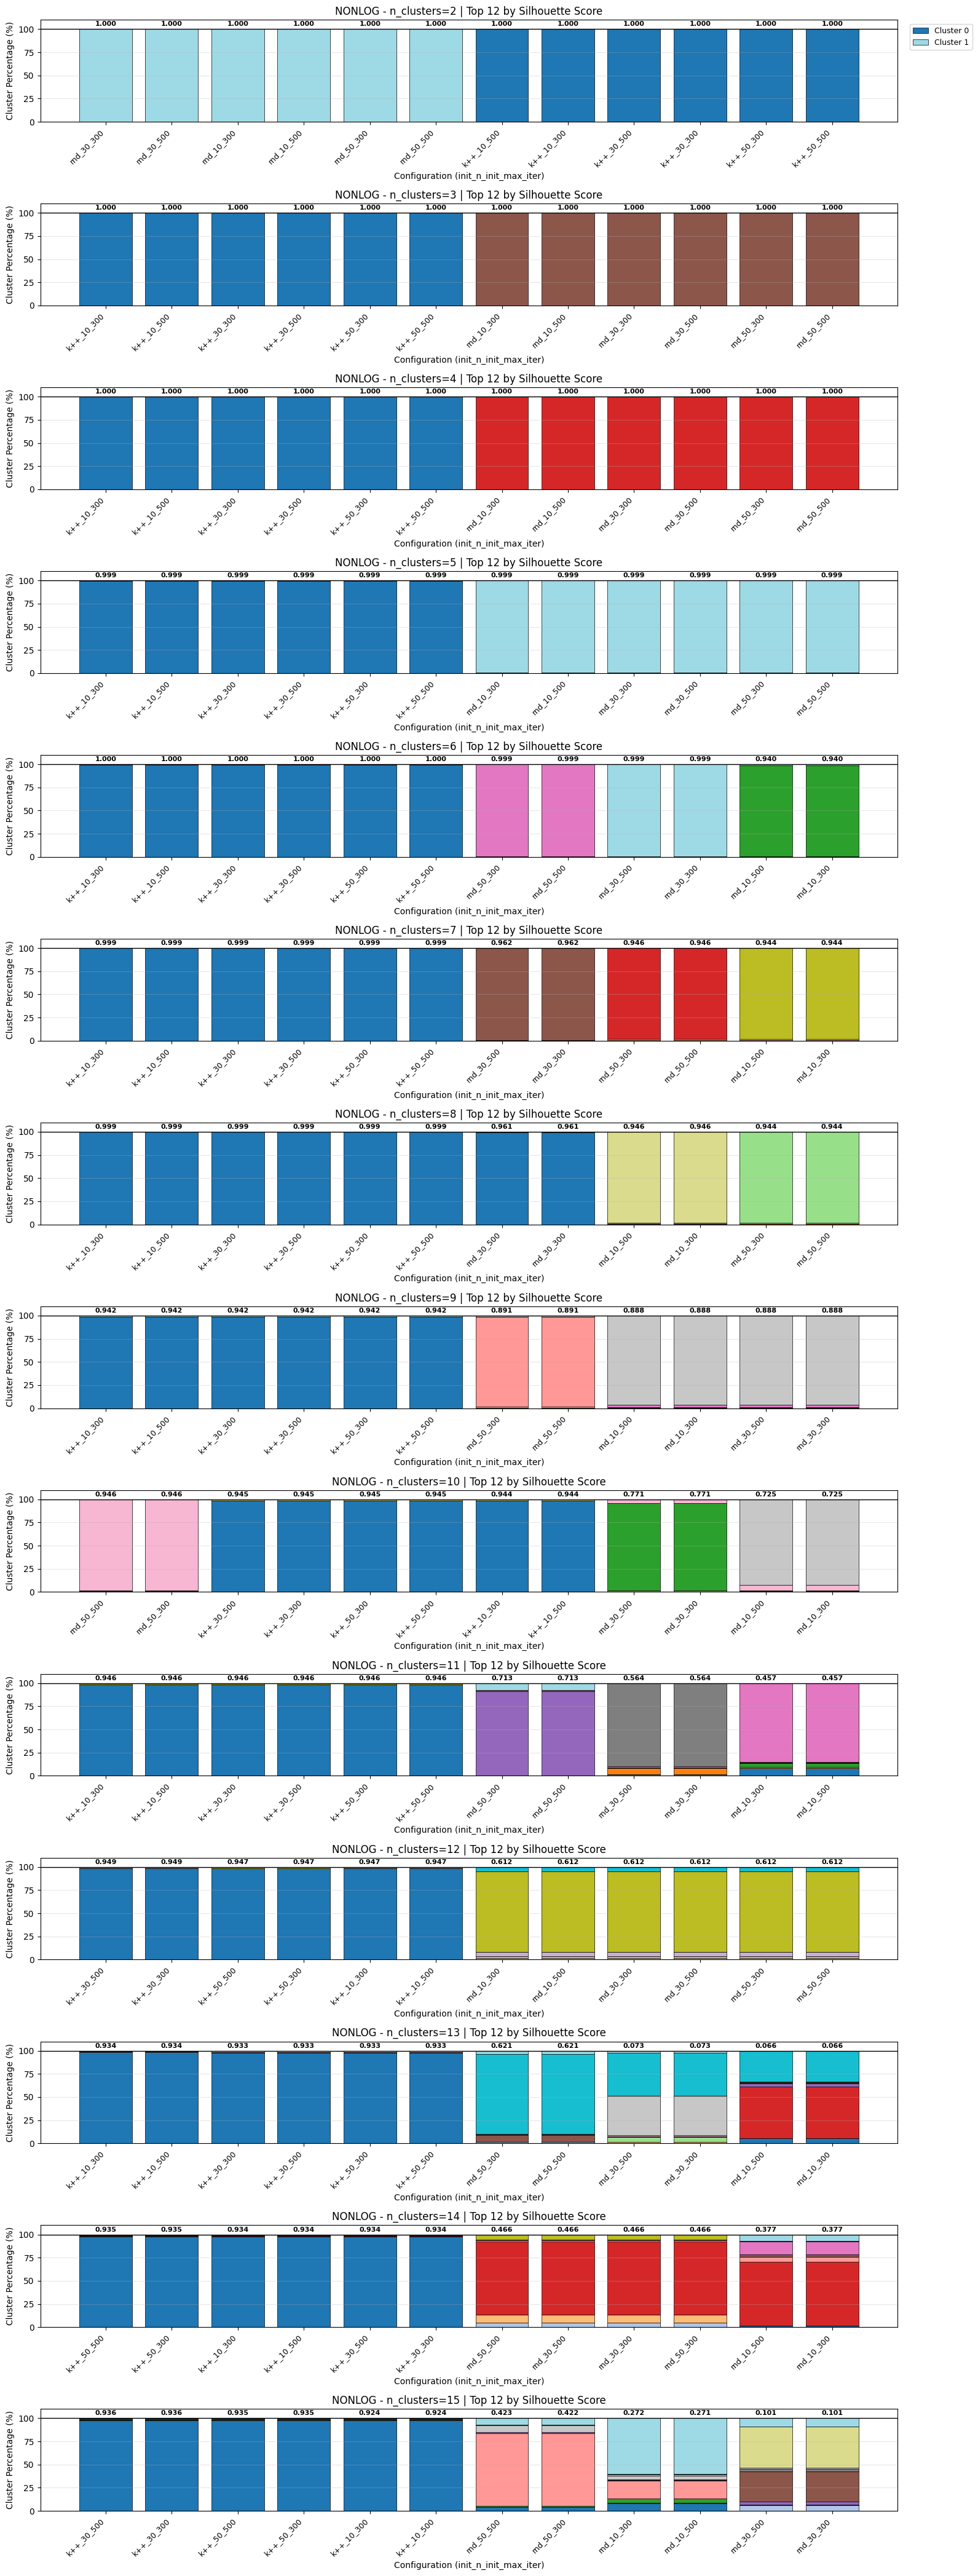

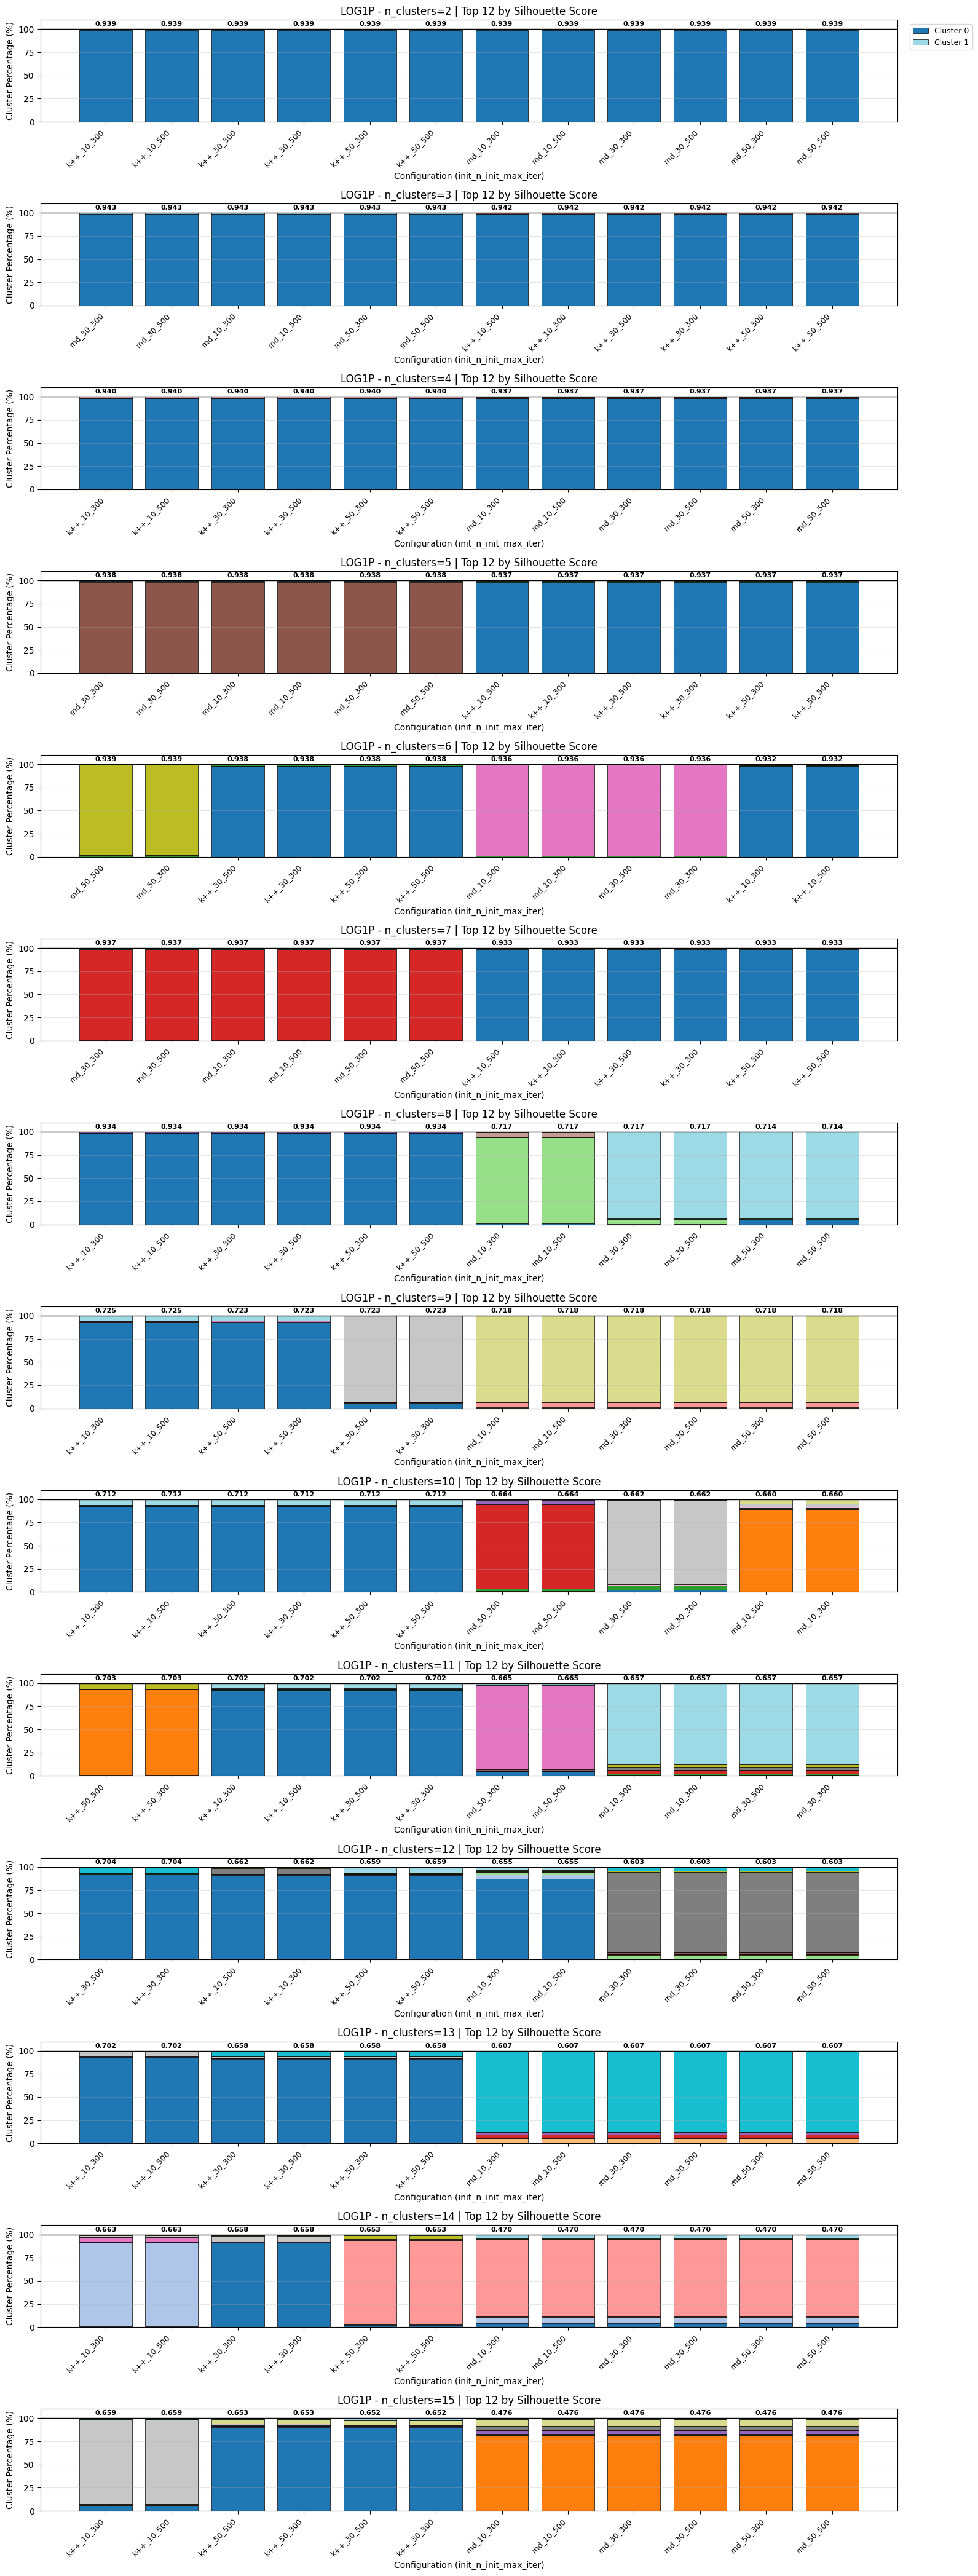


SUMMARY STATISTICS FOR EACH DATASET

NONLOG:
  Total configurations tested: 168

  Best by Silhouette Score:
    n_clusters=2, score=0.9998, max_cluster_pct=100.0%

  Best by Cluster Balance (most even):
    n_clusters=15, score=0.1010, balance=0.5520, max_cluster_pct=44.8%

  Silhouette Score Distribution:
    Mean: 0.8679
    Median: 0.9460
    Std Dev: 0.2275
    Min: 0.0661
    Max: 0.9998

LOG1P:
  Total configurations tested: 168

  Best by Silhouette Score:
    n_clusters=3, score=0.9430, max_cluster_pct=98.6%

  Best by Cluster Balance (most even):
    n_clusters=15, score=0.4761, balance=0.1837, max_cluster_pct=81.7%

  Silhouette Score Distribution:
    Mean: 0.7829
    Median: 0.7204
    Std Dev: 0.1554
    Min: 0.4702
    Max: 0.9430


In [ ]:
# Visualization of all trained models - Grid showing cluster distributions
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

for variant, X_data in datasets.items():
    results_df = all_models_results[variant]
    
    # Get unique n_clusters values
    n_clusters_vals = sorted(results_df['n_clusters'].unique())
    
    # Create subplots: one for each n_clusters
    fig, axes = plt.subplots(len(n_clusters_vals), 1, figsize=(16, 3*len(n_clusters_vals)))
    if len(n_clusters_vals) == 1:
        axes = [axes]
    
    for idx, n_clust in enumerate(n_clusters_vals):
        ax = axes[idx]
        
        # Get all configurations for this n_clusters
        subset = results_df[results_df['n_clusters'] == n_clust].copy()
        subset = subset.sort_values('silhouette_score', ascending=False)
        
        # Prepare data for stacked bar chart
        max_display = 20  # Show top 20 configurations
        subset = subset.head(max_display)
        
        config_labels = [f"k++_{int(row['n_init'])}_{int(row['max_iter'])}" if row['init']=='k-means++' 
                         else f"rnd_{int(row['n_init'])}_{int(row['max_iter'])}" 
                         for _, row in subset.iterrows()]
        silhouette_scores = subset['silhouette_score'].values
        
        # Create color map for clusters
        colors = plt.cm.tab20(np.linspace(0, 1, n_clust))
        
        # Get cluster percentages for each config
        cluster_data = []
        for idx_row, (_, row) in enumerate(subset.iterrows()):
            labels = row['labels']
            _, counts = np.unique(labels, return_counts=True)
            pcts = 100 * counts / len(labels)
            # Pad with zeros if needed
            pcts_padded = np.zeros(n_clust)
            pcts_padded[:len(pcts)] = pcts
            cluster_data.append(pcts_padded)
        
        cluster_data = np.array(cluster_data)
        
        # Create stacked bar chart
        x_pos = np.arange(len(config_labels))
        bottom = np.zeros(len(config_labels))
        
        for cluster_id in range(n_clust):
            ax.bar(x_pos, cluster_data[:, cluster_id], bottom=bottom, 
                   label=f'Cluster {cluster_id}', color=colors[cluster_id], edgecolor='black', linewidth=0.5)
            bottom += cluster_data[:, cluster_id]
        
        # Overlay silhouette scores as text
        for i, (score, label) in enumerate(zip(silhouette_scores, config_labels)):
            ax.text(i, 102, f'{score:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        ax.set_ylabel('Cluster Percentage (%)')
        ax.set_xlabel('Configuration (init_n_init_max_iter)')
        ax.set_title(f"{variant.upper()} - n_clusters={n_clust} | Top {min(max_display, len(subset))} by Silhouette Score")
        ax.set_xticks(x_pos)
        ax.set_xticklabels(config_labels, rotation=45, ha='right', fontsize=9)
        ax.set_ylim([0, 110])
        ax.axhline(y=100, color='black', linestyle='-', linewidth=1)
        ax.grid(axis='y', alpha=0.3)
        
        if idx == 0:
            ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, ncol=1)
    
    plt.tight_layout()
    plt.show()

# Summary statistics table
print(f"\n{'='*80}")
print("SUMMARY STATISTICS FOR EACH DATASET")
print(f"{'='*80}")

for variant in datasets.keys():
    results_df = all_models_results[variant]
    print(f"\n{variant.upper()}:")
    print(f"  Total configurations tested: {len(results_df)}")
    print(f"\n  Best by Silhouette Score:")
    best_sil = results_df.nlargest(1, 'silhouette_score').iloc[0]
    print(f"    n_clusters={int(best_sil['n_clusters'])}, score={best_sil['silhouette_score']:.4f}, max_cluster_pct={best_sil['max_cluster_pct']:.1f}%")
    
    print(f"\n  Best by Cluster Balance (most even):")
    best_balance = results_df.nlargest(1, 'cluster_balance').iloc[0]
    print(f"    n_clusters={int(best_balance['n_clusters'])}, score={best_balance['silhouette_score']:.4f}, balance={best_balance['cluster_balance']:.4f}, max_cluster_pct={best_balance['max_cluster_pct']:.1f}%")
    
    # Distribution of silhouette scores
    print(f"\n  Silhouette Score Distribution:")
    print(f"    Mean: {results_df['silhouette_score'].mean():.4f}")
    print(f"    Median: {results_df['silhouette_score'].median():.4f}")
    print(f"    Std Dev: {results_df['silhouette_score'].std():.4f}")
    print(f"    Min: {results_df['silhouette_score'].min():.4f}")
    print(f"    Max: {results_df['silhouette_score'].max():.4f}")